# **Dealing with Missing Values**

In [1]:
# install the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the titanic dataset that is built into seaborn
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


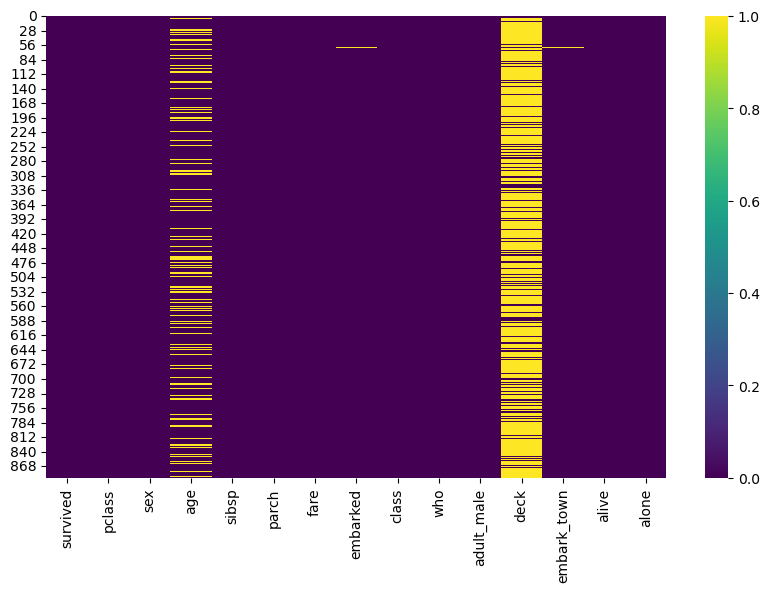

In [3]:
# create a heatmap to visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(titanic.isnull(), cmap='viridis')
plt.show()

In [4]:
# missig values in the dataset
missing_values = titanic.isnull().sum().sort_values(ascending=False)
missing_values

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [5]:
# to the see the missing values in percentage and round the values to 2 decimal places
missing_values_percentage = (titanic.isnull().sum() / len(titanic) * 100).sort_values(ascending=False).round(2)
missing_values_percentage

deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
sex             0.00
pclass          0.00
survived        0.00
fare            0.00
parch           0.00
sibsp           0.00
class           0.00
adult_male      0.00
who             0.00
alive           0.00
alone           0.00
dtype: float64

In [23]:
# now we all going to deal the missing values in the age colomn in dataset
titanic['age'] = titanic['age'].fillna(titanic['age'].mean())
titanic.isnull().sum().sort_values(ascending=False)

deck           688
embarked         2
embark_town      2
age              0
survived         0
pclass           0
sex              0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [6]:
# deck colomn has a lot of missing values, so we will drop it
titanic.drop(columns=['deck'], inplace=True)
titanic.isnull().sum().sort_values(ascending=False)

age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
parch            0
sibsp            0
class            0
fare             0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

In [7]:
# now we see in the data that embarked and embark_town has two missing values so we impute the missing values in embarked_town
titanic['embark_town'] = titanic['embark_town'].fillna(titanic['embark_town'].mode()[0])
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic.isnull().sum().sort_values(ascending=False)

age            177
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
embark_town      0
alive            0
alone            0
dtype: int64

### **We can also impute the missing values using the sk learn library**.

In [8]:
# import libraries for imputation
from sklearn.impute import SimpleImputer

In [9]:
# load the titanic dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
# we are going to impute the missing values inthe age column using the SimpleImputer class from sklearn which is univeriate 
# imputation
imputer = SimpleImputer(strategy='median')
# transform the age column
df['age'] = imputer.fit_transform(df[['age']])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
df.isnull().sum().sort_values(ascending=False)

deck           688
embarked         2
embark_town      2
age              0
survived         0
pclass           0
sex              0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

### **Multivariate imputation of missing values in the titanic dataset using the iterative imputer in sk learn library.**

In [12]:
# load the titanic dataset
df_1=sns.load_dataset('titanic')
df_1.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
# multivariate imputation of missing values in the titanic dataset using the iterative imputer in sk learn library.
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imputer = IterativeImputer(max_iter=10, random_state=0)

# impute the missing values in the age colomn
df_1['age'] = imputer.fit_transform(df_1[['age']])

In [14]:
df_1.isnull().sum().sort_values(ascending=False)

deck           688
embarked         2
embark_town      2
age              0
survived         0
pclass           0
sex              0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

### **Forword and Backword Imputation of missing values in dataset.**

In [15]:
# load the titanic dataset
df_3=sns.load_dataset('titanic')

In [16]:
df_3.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [17]:
# forword fill imputation of missing values in the dataset
df_3['age'] = df_3['age'].ffill()

In [18]:
# backward fill imputation of missing values in the dataset
df_3['age'] = df_3['age'].bfill()

### **Imputation of missing values using the KNN imputer.**

In [19]:
# now we do the imputation using the knn imputer
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=2)
df_3['age'] = imputer.fit_transform(df_3[['age']])

- we  see the embarked and embrked_town colomn has two missing values we can impute or drop the values , when we drop we simple drop the entire row that has a missing value in it.